# Classification Tutorial - Part 1 - SVM

**Objective of this Notebook:**

The goal of this notebook is to familiarize you with the functioning of **Support Vector Machines (SVMs)** and to understand how they can be used to separate data in a linear manner. By following this notebook, you will be able to:

- Understand the concept of a **support vector** and its role in SVMs
- Work with **linearly separable data** and identify cases where this assumption is valid
- Build and interpret a **confusion matrix** to evaluate the performance of a classification model
- Split data into a **training dataset** and a **test dataset** to validate the model’s performance
- Compute and interpret the metrics of **accuracy**, **precision**, and **recall** to evaluate your model’s performance


___

▶️ **Import the necessary libraries**


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.svm import SVC
import imageio
from IPython.display import Image, display

___
▶️ **Run the code** to create the function for displaying the plots


In [4]:
def afficher_graphique(
    X, y,                        # X = input data, y = associated classes
    titre="",                    # Figure title, default: empty
    xlabel="Feature 1",          # x-axis label, default: 'Feature 1'
    ylabel="Feature 2",          # y-axis label, default: 'Feature 2'
    w0=None, w1=None, w2=None,   # w0 and w=[w1,w2]^T, parameters defining the separating hyperplane
    svm=None,                    # trained SVM output, used to highlight the margin
    support=None,                # matrix containing support vectors (each row = one support vector)
):
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    
    # Data
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
    
    # Decision boundary
    if w0 and w1 and w2 is not None:
        x_values = np.array([X[:, 0].min(), X[:, 0].max()])
        y_values = -(w0 + w1 * x_values) / w2
        ax.plot(x_values, y_values, 'g-', label='Decision boundary')
        
    # Support vectors and margin visualization
    if svm and support is not None:
        xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                             np.linspace(X[:, 1].min(), X[:, 1].max(), 100))
        Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=['gray', 'gray', 'gray'])
        ax.scatter(support[:, 0], support[:, 1], s=100,
                   facecolors='none', edgecolors='green', label='Support vectors')
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    fig.suptitle(titre, fontsize=16, y=.95)
    plt.show()

___
▶️ **Import and display the data** to be classified

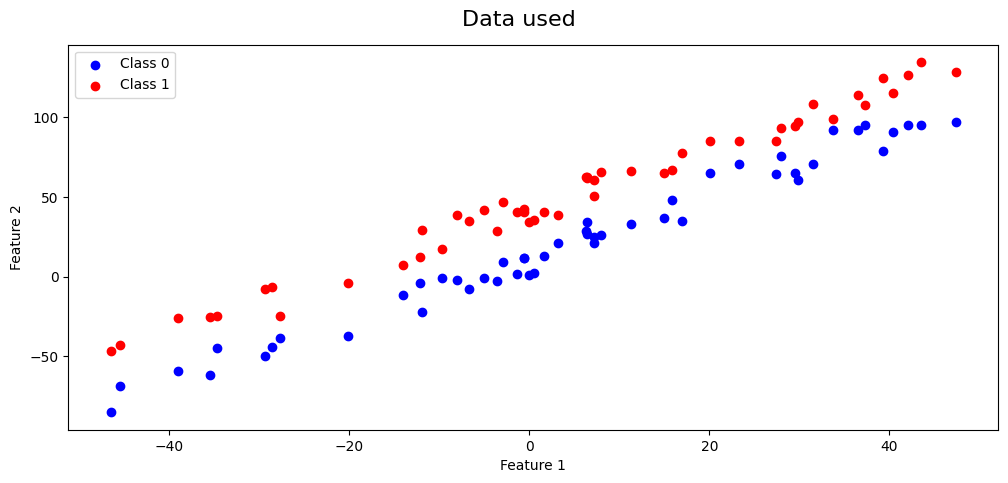

In [7]:
# Loading of the dataset
data = pd.read_csv('data_class_1.csv')
X = data.iloc[:, :2].to_numpy() # input data
y = data.iloc[:, 2].to_numpy() # class of the data
afficher_graphique(X, y, titre="Data used") # display of the data


___
## Part 1.1: Training an SVM

<div><img src="Loupe.jpg" alt="drawing" width="20"/>
<b>Links to the documentation:</b>
</div>

- kernel choice: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- training the model: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.fit
- retrieving SVM parameters: attributes intercept_ and coef_

#### 💻 Code to complete


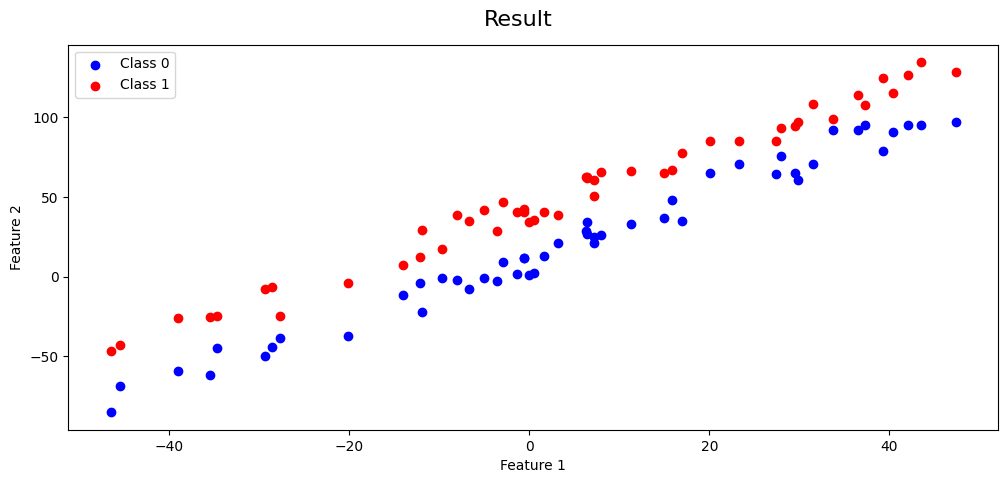

In [ ]:
# Create and train the SVM
clf = SVC().fit(X, y)

# Display the result
afficher_graphique(X, y, titre="Result", svm=clf)



#### 💻 Code to complete


In [ ]:
# Display coordinates of support vectors
print()

# Display the number of support vectors per class
print()


In [ ]:
# Highlighting the margin and identifying the support vectors
afficher_graphique(
    X, y,
    w0=, w1=, w2=,
    svm=clf, support=clf.support_vectors_,
)


___
## Part 1.2: Validation of training

### 1.2.1 Simple validation: training data and test data


### Train/Test split and model training

<div><img src="Loupe.jpg" alt="drawing" width="20"/>
<b>Links to the documentation:</b>
</div>

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

#### 💻 Code to complete


In [ ]:
X_train, X_test, y_train, y_test = train_test_split()

clf_Val = SVC().fit()

afficher_graphique(
    X_train, y_train,
    w0=, w1=, w2=,
    svm=clf_Val, support=clf_Val.support_vectors_,
)

### Model evaluation on the training data

<div><img src="Loupe.jpg" alt="drawing" width="20"/>
<b>Links to the documentation:</b>
</div>

- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html


#### 💻 Code to complete


In [ ]:
# Predictions for the training data
y_train_pred = clf_Val.predict()


# Computation of the confusion matrix on the training data
cm_train = confusion_matrix()


# Classification report for the training data
report_train = classification_report(, target_names=[str(cl) for cl in clf.classes_])


In [ ]:
# Display of the confusion matrix computed on the training data
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=clf_Val.classes_)
disp_train.plot(ax=ax, values_format='d')

ax.set_title("Confusion matrix on the training set")
for texts in disp_train.text_.ravel():
    texts.set_fontsize(16)
plt.tight_layout()
plt.show()


In [1]:
# Display of the classification report on the training set
print("Classification report on the training set:\n", report_train)

NameError: name 'report_train' is not defined

### Model evaluation on the test set

#### 💻 Code to complete


In [ ]:
# Predictions for the test data
y_test_pred = clf_Val.predict()

# Computation of the confusion matrix on the test data
cm_test = confusion_matrix(, )

# Classification report for the test data
report_test = classification_report(, , target_names=[str(cl) for cl in clf_Val.classes_])


In [ ]:
# Display of the confusion matrix computed on the test data
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=clf.classes_)
disp_test.plot(ax=ax, values_format='d')

ax.set_title("Confusion matrix on the test set")
for texts in disp_test.text_.ravel():
    texts.set_fontsize(16)
plt.tight_layout()
plt.show()

In [ ]:
# Display of the classification report for the test data
print("Classification report on the test set:\n", report_test)


▶️ **Run the code** of the animated plot display function


In [ ]:
def creer_image(X_train, X_test, y_train, y_test):
    clf = SVC(kernel="linear").fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    # Calcul de la droite de décision
    x_values = np.array([X[:, 0].min(), X[:, 0].max()])
    y_values = -(clf.intercept_ + clf.coef_[0][0] * x_values) / clf.coef_[0][1]
    fig, ax = plt.subplots(1, 3, figsize=(16, 6))
    ax[0].scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], alpha=0.5, color='#0000ff', label='Classe 0 (entrainement)')
    ax[0].scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], alpha=0.5, color='#ff0000', label='Classe 1 (entrainement)')
    ax[0].plot(x_values, y_values, 'g-', label='Droite de décision')
    ax[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], alpha=0.5, color='#7F7FD6', label='Classe 0 (test)')
    ax[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], alpha=0.5, color='#CA887A', label='Classe 1 (test)')
    ax[0].set_xlabel("Caractéristique 1")
    ax[0].set_ylabel("Caractéristique 2")
    ax[0].legend()
    # Matrice de confusion d'entrainement
    cm_train = confusion_matrix(y_train, y_train_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=clf.classes_)
    disp_train.plot(ax=ax[1], values_format='d')
    ax[1].set_title("Matrice de confusion d'entrainement")
    for texts in disp_train.text_.ravel():
        texts.set_fontsize(16)
    # Matrice de confusion de test
    cm_test = confusion_matrix(y_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=clf.classes_)
    disp_test.plot(ax=ax[2], values_format='d')
    ax[2].set_title("Matrice de confusion de test")
    for texts in disp_test.text_.ravel():
        texts.set_fontsize(16)
    fig.suptitle(f"Entrainement d'un modèle de classification (SVM) {round(len(y_test)/(len(y_test)+len(y_train)), 2)*100}% test", fontsize=20, y=1)
    # Transformation de l'image sous forme de tableau Numpy
    canvas = plt.get_current_fig_manager().canvas
    canvas.draw()
    width, height = canvas.get_width_height()
    image_str = canvas.buffer_rgba()
    image_np = np.frombuffer(image_str, dtype=np.uint8).reshape(height, width, 4)
    plt.close(fig)
    return image_np

#### Impact on the confusion matrix



<div><img src="Loupe.jpg" alt="drawing" width="20"/>
<b>Links to the documentation:</b>
</div>

* https://numpy.org/doc/stable/reference/generated/numpy.arange.html
* https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html


#### 💻 Code to complete


In [ ]:
filename = "image.gif"
frames = []  # List to store intermediate images

# Loop over different test set proportions (e.g. 10% to 90%)
for size in np.arange(0.1, 1.0, 0.1):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split( )

    # Generate intermediate frame with the custom function
    intermediaire = create_image(X_train, X_test, y_train, y_test)
    frames.append(intermediaire)

# Save the animation as GIF
imageio.mimsave(filename, frames, duration=1000, loop=0)

# Display the GIF in the notebook
display(Image(filename=filename))

#### Impact on the classification accuracy


▶️ **Run the code** for the accuracy computation and plot display functions


In [ ]:
def acc(X_train, X_test, y_train, y_test):
    # Train the model
    clf = SVC(kernel="linear").fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    # Compute accuracy
    acc_train = clf.score(X_train, y_train)
    acc_test = clf.score(X_test, y_test)
    return acc_train, acc_test


def afficher_acc(
    percentage_test, # X-axis vector containing the percentage of the test set relative to the full dataset
    acc_train,       # Accuracy on the training set
    acc_test         # Accuracy on the test set
):
    plt.figure(figsize=(10, 6))
    plt.plot(percentage_test, 100*acc_train, label='Training accuracy', color='blue')
    plt.plot(percentage_test, 100*acc_test, label='Test accuracy', color='red')
    plt.xlabel('Proportion of test size [%]')
    plt.ylabel('Accuracy [%]')
    plt.ylim((0, 105))
    plt.title("Accuracy curves for training and test sets")
    plt.legend()
    plt.grid(True)
    plt.show()


#### 💻 Code to complete


In [ ]:
# Initialize empty arrays
acc_train = np.empty(0)
acc_test  = np.empty(0)

# Range of test set proportions (from 0.1 to 0.9 with step 0.1, for example)
percentage_test = np.arange(0.1, 1.0, 0.1)

# Loop over different train/test splits
for size in percentage_test:
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split()

    # Evaluate model performance with custom function acc()
    temp_train, temp_test = acc(X_train, X_test, y_train, y_test)

    # Store results
    acc_train = np.append(acc_train, temp_train)
    acc_test  = np.append(acc_test, temp_test)

# Plot accuracy evolution
afficher_acc(percentage_test, acc_train, acc_test)
